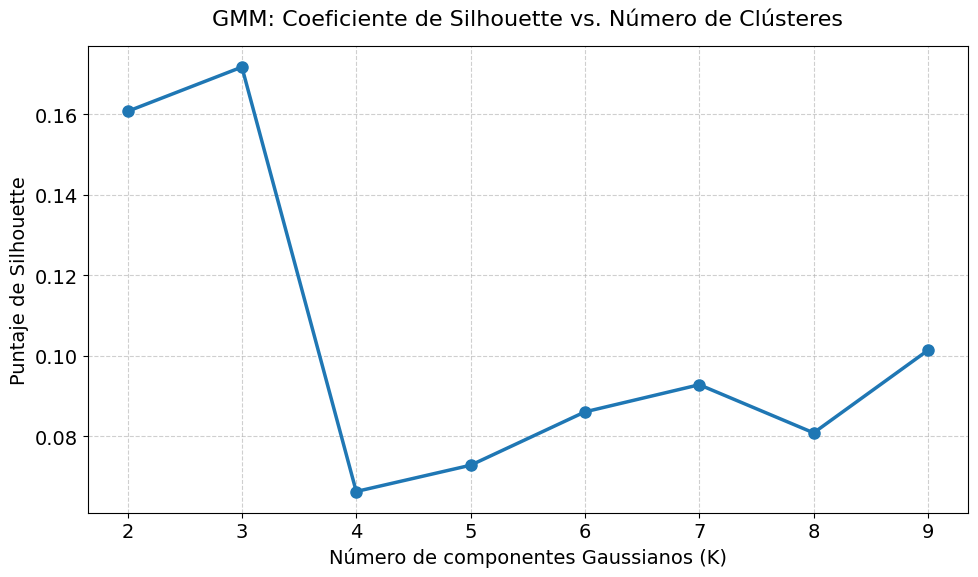

El número óptimo de clústeres es K = 3 con un Silhouette de 0.172


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1. Configuración estricta de tamaño de fuente para evitar penalizaciones (>= 14)
plt.rcParams.update({'font.size': 14})

# 2. Carga de datos y preprocesamiento
# Asegúrate de que el archivo 'eco_acoustic_train.csv' esté en la misma carpeta
df = pd.read_csv('eco_acoustic_train.csv')

# Extraer únicamente las 64 columnas correspondientes a las características espectrales (Mel)
X = df.loc[:, 'mel_0':'mel_63']

# Estandarizar el espacio vectorial
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Cálculo del Coeficiente de Silhouette iterando el número de clústeres en GMM
k_values = range(2, 10)
silhouette_scores = []

for k in k_values:
    # Definir y entrenar el modelo probabilístico (GMM)
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    
    # Calcular y almacenar el Coeficiente de Silhouette
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# 4. Generación de la visualización geométrica
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8)

# Configuración de etiquetas y título con tamaño exigido
plt.title('GMM: Coeficiente de Silhouette vs. Número de Clústeres', fontsize=16, pad=15)
plt.xlabel('Número de componentes Gaussianos (K)', fontsize=14)
plt.ylabel('Puntaje de Silhouette', fontsize=14)

# Configuración de los ejes
plt.xticks(k_values, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Guardar la gráfica para adjuntar en LaTeX
plt.tight_layout()
plt.savefig('silhouette_gmm.png', dpi=300, bbox_inches='tight')

# Mostrar la gráfica en el notebook
plt.show()

# Imprimir el valor óptimo en consola para verificación
mejor_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"El número óptimo de clústeres es K = {mejor_k} con un Silhouette de {max(silhouette_scores):.3f}")